# Initial Checks

In [1]:
import pandas as pd

df = pd.read_csv(
    "/content/한국교육학술정보원_대학학과커리큘럼_강의계획서_20221227.csv",
    encoding="cp949"
)

print(df.columns)
print(df.head())

Index(['연도', '대학교명', '단과대학명', '학부 과명', '과목명', '학년', '학기', '학점', '이론시간', '실습시간',
       '과목구분', '학습목표', '주교재', '부교재', '참고자료', '선행학습자료'],
      dtype='object')
     연도   대학교명 단과대학명 학부 과명     과목명 학년   학기   학점  이론시간  실습시간  과목구분  \
0  2022  강원대학교  간호대학  간호학과    간호용어  1  2학기  2.0   2.0     0  전공선택   
1  2022  강원대학교  간호대학  간호학과    간호용어  1  2학기  2.0   2.0     0  전공선택   
2  2022  강원대학교  간호대학  간호학과  성인간호학3  3  1학기  2.0   2.0     0  전공필수   
3  2022  강원대학교  간호대학  간호학과  성인간호학3  3  1학기  2.0   2.0     0  전공필수   
4  2022  강원대학교  간호대학  간호학과  성인간호학4  3  1학기  2.0   2.0     0  전공필수   

                                                학습목표  \
0  간호용어에 관한 전문적 지식을 갖추어 다른 간호전공과목을 이해할 수 있는 역량을 갖춘다.   
1  간호용어에 관한 전문적 지식을 갖추어 다른 간호전공과목을 이해할 수 있는 역량을 갖춘다.   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                                                 주교재                      부교재  \
0  1.\t박경

/tmp/ipykernel_1466/4224969380.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [2]:
# Check the column headers

df.columns.tolist()

['연도',
 '대학교명',
 '단과대학명',
 '학부 과명',
 '과목명',
 '학년',
 '학기',
 '학점',
 '이론시간',
 '실습시간',
 '과목구분',
 '학습목표',
 '주교재',
 '부교재',
 '참고자료',
 '선행학습자료']

In [3]:
# Determine missingness in column information

for col in df.columns:
    print(col, df[col].isna().mean())

연도 0.0
대학교명 0.0
단과대학명 0.0
학부 과명 0.0
과목명 0.0
학년 0.0
학기 0.0
학점 0.0
이론시간 0.0
실습시간 0.0
과목구분 0.0
학습목표 0.1818730850813104
주교재 0.22753653075654018
부교재 0.9013816874852698
참고자료 0.616088263021447
선행학습자료 0.6655520857883573


In [4]:
df["학습목표"].str.len().describe()

,학습목표
count,55541.000000
mean,173.393835
std,166.358737
min,1.000000
25%,77.000000
50%,125.000000
75%,218.000000
max,5259.000000


In [5]:
df["학습목표"].fillna("").str.len().describe()

,학습목표
count,67888.000000
mean,141.858163
std,164.667648
min,0.000000
25%,41.000000
50%,97.000000
75%,192.000000
max,5259.000000


In [6]:
# Get a sense of information listed in 학습목표

df["학습목표"].dropna().sample(10, random_state=42)

,학습목표
53030,"현재 발달하고 있거나, 발전이 예상되는 혁신적인 치의학의 분야에 대한 지식을 습득하..."
51444,This course primarily aims at providing a broa...
46070,* 진로설계 및 실행역량 강화 자기이해 역량강화 직업정보 탐색역량 강화 ...
59218,"""교육에 대한 기본적인 이해를 중심으로 교육학을 학교 현장에서, 그리고 개인의 삶에..."
65437,[프로그램 학습성과](1) 다양한 전공지식에 근거한 간호술을 통합적으로 실무에 적용...
5872,금속재료중 철강재료의 원리를 이해하고 새로운 철강재료를 개발하기 위한 공학적 지식을...
43648,"""교양수학 홈페이지 http://www.math.snu.ac.kr/board/tao..."
9207,"그룹활동을 통해 협업하는능력, 다양한 종류의 질문의 사용을 통해 대화를 확장하는능..."
2942,관련분야의 취업 방향설정과 가능성 타진
65647,Les m&eacute;thodes de travail seront ludiques...


In [7]:
# Noting that not everything is in Korean, check proportion

import re

def contains_korean(text):
    return bool(re.search(r'[가-힣]', str(text)))

df["is_korean"] = df["학습목표"].apply(contains_korean)

df["is_korean"].value_counts(normalize=True)

,proportion
is_korean,
True,0.767971
False,0.232029


# Load the Education Datasets

In [8]:
curriculum = pd.read_csv(
    "/content/한국교육학술정보원_대학학과커리큘럼_강의계획서_20221227.csv",
    encoding="cp949"
)

mapping = pd.read_csv(
    "/content/department_mapping.csv"
)

/tmp/ipykernel_1466/2363894204.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  curriculum = pd.read_csv(


In [9]:
print(curriculum.columns.tolist())

['연도', '대학교명', '단과대학명', '학부 과명', '과목명', '학년', '학기', '학점', '이론시간', '실습시간', '과목구분', '학습목표', '주교재', '부교재', '참고자료', '선행학습자료']


In [10]:
print(mapping.columns.tolist())

['Department (Korean)', 'Department (English)', 'Domain', 'Reason', 'Unnamed: 4']


# Prepare the Education Dataset

## Map the two files

In [11]:
curriculum_domain = curriculum.merge(
    mapping,
    left_on="학부 과명",
    right_on="Department (Korean)",
    how="inner"
)

In [12]:
curriculum_domain["Domain"].value_counts()

,count
Domain,
Business/Economics,2681
Computing,1488
Stats/Data/AI,773
Industrial Engineering,647
KIV,456


In [13]:
curriculum_domain.groupby("Domain")["학습목표"].apply(
    lambda x: x.isna().mean()
)

,학습목표
Domain,
Business/Economics,0.287952
Computing,0.104839
Industrial Engineering,0.061824
KIV,0.054825
Stats/Data/AI,0.252264


## Save the mapped file

In [14]:
curriculum_domain.to_csv(
    "/content/curriculum_with_domains.csv",
    index=False,
    encoding="cp949"
)

In [15]:
curriculum_domain.groupby("Domain")["학습목표"].apply(
    lambda x: x.notna().sum()
)

,학습목표
Domain,
Business/Economics,1909
Computing,1332
Industrial Engineering,607
KIV,431
Stats/Data/AI,578


## Checking the text

Within course objectives, checking the available text to get a sense of whether the domain mapping is correct

In [16]:
for domain in curriculum_domain["Domain"].unique():

    print("\n")
    print("=" * 80)
    print(domain)

    sample = (
        curriculum_domain[
            curriculum_domain["Domain"] == domain
        ]["학습목표"]
        .dropna()
        .sample(5, random_state=42)
    )

    for text in sample:
        print("\n---")
        print(text[:500])



Business/Economics

---
* 진로설계 및 실행역량 강화   자기이해 역량강화   직업정보 탐색역량 강화   의사결정 역량강화   직업기초능력/ 구직기술/ 자기개발 역량 강화

---
중급회계에 대한 지식 습득

---
학생들에게 환율의 결정 및 환산에 대한 명확한 지식을 주입시키고 여러가지 종류의 환율 특징 및 필요성을 이해하게 하여 글로벌 기업환경에서 글로벌 기업들이 영업 및 재무활동을 할 때 현지화폐와 본국화폐 또는 기축화폐등 여러화폐의 사용으로 인하여 발생하는 복잡한 회계 및 재무업무를 쉽게 파악하는데 도움을 주는 강의가 되도록 한다. 또한 환율의 변동으로 인하여 영업활동과 관계없이 발생할 수 있는 글로벌기업의 손실을 방지하기 위한 여러가지 파생상품의 활용법을 학생들에게 학습시켜 학생들을 글로벌시대의 재무관리자로 양성하는 것이 이 과목의 학습목표이다. 문제를 새롭게 파악하고 정의하며 해결하는 능력배양(창의성) 경영이론과 의사소통방법을 숙지하고 경영지식을 현실에 적용하는 능력배양  (전문성)

---
본 강의는 공기업과 공공기관의 입사를 희망하는 학생들의 기초역량을 증진시키기 위한 과목으로 공기업과 공공기관에 대한 소개와 주요 사업 및 핵심 업무들에 대하여 기초적인 지식을 함양한다.

---
화폐 및 금융제도를 이해하고, 중앙은행의 통화정책이 실물경제에 어떻게 영향을 미치는지 살펴본다.


Stats/Data/AI

---
통계적 의사결정에 사용되는 기초 분석방법들을 배우고 실제 데이터기반 분석을 경험하여 스스로 통계적 의사결정에 기여할 수 있도록 한다.다양한 데이터의 유형에 따라 의사결정의 방법들이 달라질 것이고 그에 따른 분석방법의 변화를 파악할 수 있는 능력을 배양하고자 한다.

---
본 과목은 데이터 사이언스 전반에 대한 이해를 위해 실무중심의 다양한 사례를 다루게 됨.   예시)      공공데이터로 무엇을 할 수 있을까     청주에서 미세먼지가 가장 심한 곳은      기본적인 분석을 위해 알아야할 기초적인 통계는 무엇이

Generating samples for visualisation purposes

In [17]:
for domain in ["Computing", "Industrial Engineering"]:

    print("\n")
    print("=" * 80)
    print(domain)

    domain_df = curriculum_domain[
        curriculum_domain["Domain"] == domain
    ].copy()

    # Drop missing learning objectives first
    texts = domain_df["학습목표"].dropna()

    print("\n[Korean candidates]")
    korean_texts = texts[
        texts.str.contains("[가-힣]", regex=True, na=False)
    ]

    for text in korean_texts.sample(10, random_state=42):
        print("\n---")
        print(text[:300])

    print("\n[English candidates]")
    english_texts = texts[
        ~texts.str.contains("[가-힣]", regex=True, na=False)
    ]

    for text in english_texts.sample(5, random_state=42):
        print("\n---")
        print(text[:500])



Computing

[Korean candidates]

---
새로운 인공지능의 시대를 준비하는 시점에 컴퓨터, 전자, 정보통신, 기계 등 융합 기술을 전공하는 공학도와 인공지능을 처음 접하는 컴퓨터 비전공자들도 다양한 예제와 실습을 통해 인공지능의 기초적인 개념과 이론을 익힐 수 있다. 인공지능의 기본적인 이론을과 딥러닝을 포함하여 기계학습을 설명하고자한다. 딥러닝 분야는 구글의 텐서플로우를 기본으로 고수준 라이브러리인 Keras를 사용하여 실습할 수 있으며, 구글의 텐서플로우 플레이그라운드를 이용하여 체험할 수 있도록 한다

---
인공지능 기술 중 가장 주목받고 있는 신경망을 이용한 기계학습 및 딥러닝 기술의 기초 이론 및 활용 분야를 살펴보고, 미래를 전망해 본다.인공지능 구현에 필요한 핵심 이론인 컨볼루션 신경망, 순환 신경망, 강화 학습 등의 딥러닝 주제로 인공지능을 학습한다.복잡한 수식이나 코딩, 어려운 작동 원리에 집중하기보다는 더욱 손쉽게 딥러닝 인공지능 지식이 부족하여도 미리 제작된 다양한 예제를 통해 손쉽게 인공지능 기술을 활용해 본다

---
IoT 분야에서 널리 사용되는 하드웨어 소개 IoT 하드웨어의 동작원리 이해 IoT 하드웨어의 제어 및 프로그래밍 방법 학습 IoT 하드웨어의 인터페이스에 대한 이해 및 활용방법 학습

---
다양한 수치해석 기법을 이해함.각 응용 분야에 대해 목적에 맞는 수치해석 기법을 선택하여 적용함.

---
운영체제의 개념과 발전과정, 구성요소 및 동작 원리 이해 프로세스 개념 및 관리, 스케줄링, 동기화 학습 병행 프로그래밍, 교착상태, 주기억장치/보조기억장치, 파일시스템 이해 시스템에 최적화된 소프트웨어 개발 능력 배양

---
본 교과목은 프로그래밍 개발 역량을 배양하기 위해 C 프로그래밍 언어를 이용하여 프로그래밍의 기초, 구조적 프로그래밍 등 프로그래밍 기본 원리와 S/W 개발의 기본 원칙을 학습한다. 

---
* 진로설계 및 실행역량 강화   자기이해 역량강화   직업정보 탐색역량 강화   

## Corpus construction

In [18]:
domain_df = curriculum_domain[
    curriculum_domain["Domain"] != "KIV"
].copy()

domain_df = domain_df.dropna(subset=["학습목표"])

In [19]:
domain_corpora = (
    domain_df
    .groupby("Domain")["학습목표"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
)

In [20]:
domain_df.groupby("Domain").size()

,0
Domain,
Business/Economics,1909
Computing,1332
Industrial Engineering,607
Stats/Data/AI,578


In [21]:
domain_df = curriculum_domain[
    (curriculum_domain["Domain"] != "KIV") &
    (curriculum_domain["학습목표"].notna())
].copy()

In [22]:
domain_df.to_csv(
    "/content/curriculum_clean.csv",
    index=False,
    encoding="cp949"
)

## Aggregated corpus

In [23]:
# Keeping only required columns
edu_clean = domain_df[[
    "Domain", "대학교명", "단과대학명", "학부 과명", "과목명", "학습목표"
]].copy()

# Remove duplicate learning objectives within each domain
edu_dedup = (
    edu_clean
    .dropna(subset=["학습목표"])
    .drop_duplicates(subset=["Domain", "학습목표"])
    .copy()
)

domain_corpora = (
    edu_dedup
    .groupby("Domain")["학습목표"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
    .rename(columns={"학습목표": "education_text"})
)

domain_corpora["text_length"] = domain_corpora["education_text"].str.len()
domain_corpora[["Domain", "text_length"]]

,Domain,text_length
0,Business/Economics,232999
1,Computing,111478
2,Industrial Engineering,49343
3,Stats/Data/AI,40366


In [24]:
edu_dedup.groupby("Domain").size()

,0
Domain,
Business/Economics,1245
Computing,645
Industrial Engineering,367
Stats/Data/AI,348


In [25]:
edu_clean.groupby("Domain").size()

,0
Domain,
Business/Economics,1909
Computing,1332
Industrial Engineering,607
Stats/Data/AI,578


In [26]:
domain_corpora.to_csv(
    "/content/domain_corpora.csv",
    index=False,
    encoding="utf-8-sig"
)

## Language proportion check

In [27]:
# English proportion check

domain_df["contains_english"] = (
    domain_df["학습목표"]
    .astype(str)
    .str.contains(r"[A-Za-z]", regex=True)
)

domain_df.groupby("Domain")["contains_english"].mean()

,contains_english
Domain,
Business/Economics,0.236249
Computing,0.381381
Industrial Engineering,0.291598
Stats/Data/AI,0.307958


In [28]:
# Korean proportion check

import re

def contains_korean(text):
    return bool(re.search(r"[가-힣]", str(text)))

domain_df["contains_korean"] = (
    domain_df["학습목표"]
    .astype(str)
    .apply(contains_korean)
)

domain_df.groupby("Domain")["contains_korean"].mean()

,contains_korean
Domain,
Business/Economics,0.943426
Computing,0.881381
Industrial Engineering,0.927512
Stats/Data/AI,0.918685


In [29]:
import re

def korean_ratio(text):
    text = str(text)
    korean_chars = len(re.findall(r"[가-힣]", text))
    return korean_chars / max(len(text), 1)

def english_ratio(text):
    text = str(text)
    english_chars = len(re.findall(r"[A-Za-z]", text))
    return english_chars / max(len(text), 1)

domain_df["korean_ratio"] = domain_df["학습목표"].apply(korean_ratio)
domain_df["english_ratio"] = domain_df["학습목표"].apply(english_ratio)

domain_df.groupby("Domain")[[
    "korean_ratio",
    "english_ratio"
]].mean()

,korean_ratio,english_ratio
Domain,,
Business/Economics,0.686340,0.062465
Computing,0.616778,0.128945
Industrial Engineering,0.667746,0.075730
Stats/Data/AI,0.656182,0.089278


In [30]:
import re

def char_breakdown(text):
    text = str(text)

    total = len(text)

    korean = len(re.findall(r"[가-힣]", text))
    english = len(re.findall(r"[A-Za-z]", text))
    digits = len(re.findall(r"[0-9]", text))
    spaces = len(re.findall(r"\s", text))

    other = total - korean - english - digits - spaces

    return pd.Series({
        "korean": korean,
        "english": english,
        "digits": digits,
        "spaces": spaces,
        "other": other
    })

sample = domain_df["학습목표"].dropna().sample(1000, random_state=42)

breakdown = sample.apply(char_breakdown).sum()

breakdown / breakdown.sum()

,0
korean,0.608416
english,0.142953
digits,0.004373
spaces,0.211309
other,0.032949


In [31]:
foreign_only = domain_df[
    domain_df["학습목표"].astype(str).str.contains(r"[A-Za-z]", regex=True)
    &
    ~domain_df["학습목표"].astype(str).str.contains(r"[가-힣]", regex=True)
]

len(foreign_only)

348

In [32]:
foreign_only["학습목표"].sample(
    min(20, len(foreign_only)),
    random_state=42
).tolist()

['Understanding the history and basic structure of the Internet and the web Understanding clientside programming through learning HTML/CSS/JavaScript Increase problem solving ability using Open API utilization',
 'The main goal of this course is to provide students with the fundamentals of probabilistic and statistical analysis commonly used in engineering and science applications.',
 'After completion of this course, the student will understand the following concepts of Discrete Mathematics such as i) counting, ii) logics and proofs, iii) sequences, and iv) basic graph theory. Students are also expected to develop a mathematical vocabulary by expressing mathematical ideas orally and in writing after the course.',
 'The purpose of this course is to provide an introductory overview of how and why people evaluate and manage risks. This course begins by fundamentals of risk and risk management. Then we examine the concept of insurance, risk pooling, limit of risksharing under incomplete i

In [33]:
foreign_only.groupby("Domain").size()

,0
Domain,
Business/Economics,106
Computing,154
Industrial Engineering,42
Stats/Data/AI,46


In [34]:
edu_dedup.groupby("Domain").size()

,0
Domain,
Business/Economics,1245
Computing,645
Industrial Engineering,367
Stats/Data/AI,348


# Prepare the Occupation Datasets

In [35]:
occupation_df = pd.read_csv("/content/occupation_manual.csv", encoding="utf-8-sig")

occupation_df["occupation_text_main"] = occupation_df["직무내용"].fillna("")

occupation_df["occupation_text_expanded"] = (
    occupation_df["직무내용"].fillna("") + " " +
    occupation_df["업무수행능력"].fillna("") + " " +
    occupation_df["지식중요도"].fillna("")
)

occupation_df.to_csv(
    "/content/occupation_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

In [36]:
occupation_df["word_count"] = (
    occupation_df["occupation_text_expanded"]
    .str.split()
    .str.len()
)

occupation_df.groupby("Domain").agg(
    n_occupations=("Occupation", "count"),
    avg_word_count=("word_count", "mean")
)

,n_occupations,avg_word_count
Domain,,
Business/Economics,3,115.666667
Computing,3,93.666667
Industrial Engineering,3,87.000000
Stats/Data/AI,3,68.333333


# Load Sentence-BERT

In [37]:
# Install sentence-transformers
!pip install -q sentence-transformers

In [38]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Generate Embeddings

In [39]:
domain_embeddings = model.encode(
    domain_corpora["education_text"].tolist(),
    normalize_embeddings=True
)

occupation_embeddings = model.encode(
    occupation_df["직무내용"].tolist(),
    normalize_embeddings=True
)

# Compute Similarity

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(
    occupation_embeddings,
    domain_embeddings
)

In [41]:
occupation_translation = {
    "클라우드 시스템 엔지니어": "Cloud System Engineer",
    "시스템소프트웨어개발자": "Systems Software Developer",
    "정보시스템운영자": "Information Systems Operator",
    "인공지능 엔지니어": "AI Engineer",
    "데이터마이너": "Data Miner",
    "빅 데이터 전문가": "Big Data Specialist",
    "경영컨설턴트": "Management Consultant",
    "투자분석가(애널리스트)": "Investment Analyst",
    "IT컨설턴트": "IT Consultant",
    "산업공학기술자": "Industrial Engineering Technician",
    "물류관리사": "Logistics Manager",
    "산업안전관리원": "Industrial Safety Manager"
}

In [42]:
similarity_df = pd.DataFrame(
    sim_matrix,
    index=occupation_df["Occupation"],
    columns=domain_corpora["Domain"]
)

similarity_df.index = similarity_df.index.map(occupation_translation)

similarity_df

Domain,Business/Economics,Computing,Industrial Engineering,Stats/Data/AI
Occupation,,,,
Cloud System Engineer,0.214102,0.511210,0.395503,0.187210
Systems Software Developer,0.310764,0.363158,0.449318,0.245924
Information Systems Operator,0.306996,0.485414,0.414158,0.269814
AI Engineer,0.335572,0.350369,0.523338,0.441381
Data Miner,0.342116,0.364958,0.578989,0.634681
Big Data Specialist,0.314311,0.331614,0.466950,0.508547
Management Consultant,0.638786,0.278605,0.438682,0.390389
Investment Analyst,0.382414,0.198491,0.405873,0.415756
IT Consultant,0.393865,0.489129,0.471183,0.371730


In [54]:
similarity_df_with_info = similarity_df.copy()

similarity_df_with_info["Assigned_Domain"] = occupation_df["Domain"].values
similarity_df_with_info["Best_Match_Domain"] = similarity_df.idxmax(axis=1)
similarity_df_with_info["Best_Match_Score"] = similarity_df.max(axis=1)

similarity_df_with_info

Domain,Business/Economics,Computing,Industrial Engineering,Stats/Data/AI,gap,Assigned_Domain,Best_Match_Domain,Best_Match_Score
Occupation,,,,,,,,
Cloud System Engineer,0.214102,0.511210,0.395503,0.187210,0.115707,Computing,Computing,0.511210
Systems Software Developer,0.310764,0.363158,0.449318,0.245924,0.086160,Computing,Industrial Engineering,0.449318
Information Systems Operator,0.306996,0.485414,0.414158,0.269814,0.071257,Computing,Computing,0.485414
AI Engineer,0.335572,0.350369,0.523338,0.441381,0.081957,Stats/Data/AI,Industrial Engineering,0.523338
Data Miner,0.342116,0.364958,0.578989,0.634681,0.055692,Stats/Data/AI,Stats/Data/AI,0.634681
Big Data Specialist,0.314311,0.331614,0.466950,0.508547,0.041597,Stats/Data/AI,Stats/Data/AI,0.508547
Management Consultant,0.638786,0.278605,0.438682,0.390389,0.200104,Business/Economics,Business/Economics,0.638786
Investment Analyst,0.382414,0.198491,0.405873,0.415756,0.009883,Business/Economics,Stats/Data/AI,0.415756
IT Consultant,0.393865,0.489129,0.471183,0.371730,0.017946,Business/Economics,Computing,0.489129


In [44]:
print(similarity_df_with_info.index.tolist())

['Cloud System Engineer', 'Systems Software Developer', 'Information Systems Operator', 'AI Engineer', 'Data Miner', 'Big Data Specialist', 'Management Consultant', 'Investment Analyst', 'IT Consultant', 'Industrial Engineering Technician', 'Logistics Manager', 'Industrial Safety Manager']


In [45]:
from collections import Counter
import re

industrial_text = domain_corpora.loc[
    domain_corpora["Domain"]=="Industrial Engineering",
    "education_text"
].iloc[0]

words = re.findall(r"[가-힣A-Za-z]+", industrial_text)

Counter(words).most_common(50)

[('및', 235),
 ('수', 125),
 ('대한', 120),
 ('있는', 91),
 ('능력을', 85),
 ('and', 79),
 ('한다', 75),
 ('본', 72),
 ('위한', 62),
 ('of', 57),
 ('다양한', 56),
 ('필요한', 54),
 ('the', 52),
 ('설계', 50),
 ('이해하고', 47),
 ('있다', 45),
 ('통해', 43),
 ('이를', 42),
 ('분석', 41),
 ('기본', 41),
 ('등의', 33),
 ('to', 33),
 ('바탕으로', 31),
 ('학습한다', 31),
 ('관한', 30),
 ('시스템', 29),
 ('통하여', 28),
 ('대해', 28),
 ('다룬다', 28),
 ('공학적', 27),
 ('이해', 27),
 ('관련', 27),
 ('또한', 27),
 ('실제', 26),
 ('지식을', 26),
 ('것을', 25),
 ('기본적인', 25),
 ('문제를', 25),
 ('방법을', 25),
 ('능력', 25),
 ('개념을', 25),
 ('실습을', 24),
 ('데이터', 23),
 ('이론을', 23),
 ('목표로', 22),
 ('등', 22),
 ('기초', 22),
 ('위해', 21),
 ('있도록', 21),
 ('원리를', 21)]

In [46]:
similarity_df.round(3)

Domain,Business/Economics,Computing,Industrial Engineering,Stats/Data/AI
Occupation,,,,
Cloud System Engineer,0.214,0.511,0.396,0.187
Systems Software Developer,0.311,0.363,0.449,0.246
Information Systems Operator,0.307,0.485,0.414,0.270
AI Engineer,0.336,0.350,0.523,0.441
Data Miner,0.342,0.365,0.579,0.635
Big Data Specialist,0.314,0.332,0.467,0.509
Management Consultant,0.639,0.279,0.439,0.390
Investment Analyst,0.382,0.198,0.406,0.416
IT Consultant,0.394,0.489,0.471,0.372


In [47]:
similarity_df["gap"] = (
    similarity_df.max(axis=1)
    - similarity_df.apply(
        lambda row: row.nlargest(2).iloc[-1],
        axis=1
    )
)

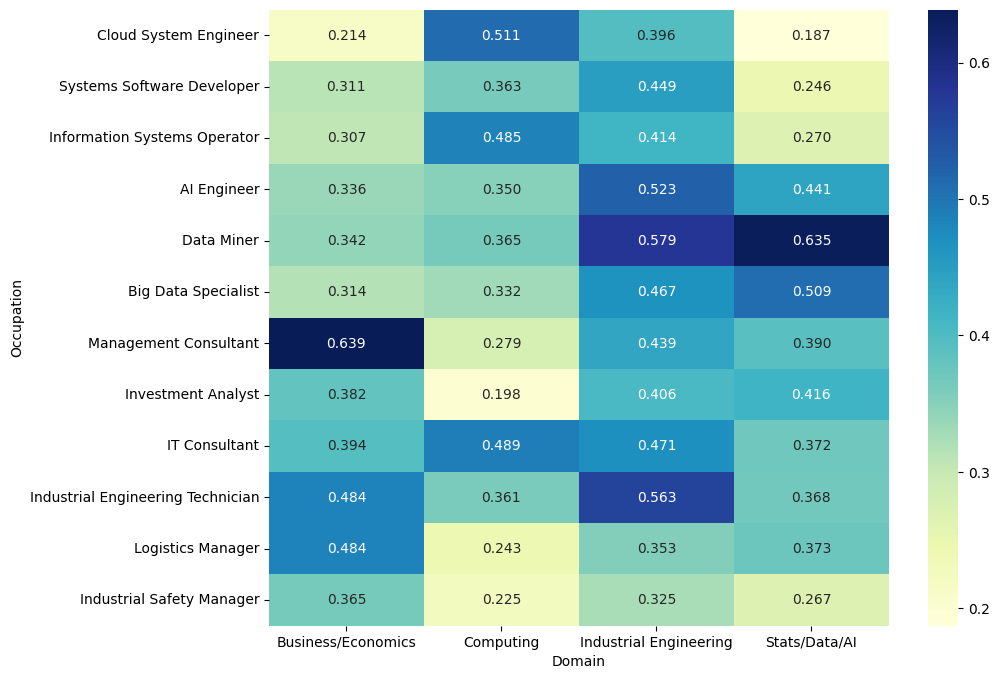

In [48]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

heatmap_df = similarity_df[
    [
        "Business/Economics",
        "Computing",
        "Industrial Engineering",
        "Stats/Data/AI"
    ]
]

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.show()

In [56]:
domain_cols = [
    "Business/Economics",
    "Computing",
    "Industrial Engineering",
    "Stats/Data/AI"
]

results = similarity_df.copy()

results["Assigned_Domain"] = occupation_df["Domain"].values

results["Best_Match_Domain"] = results[domain_cols].idxmax(axis=1)
results["Best_Match_Score"] = results[domain_cols].max(axis=1)

results["Second_Best_Score"] = results[domain_cols].apply(
    lambda row: row.nlargest(2).iloc[-1],
    axis=1
)

results["Gap"] = results["Best_Match_Score"] - results["Second_Best_Score"]

results["Matched_Assigned"] = (
    results["Assigned_Domain"] == results["Best_Match_Domain"]
)

results[
    [
        "Assigned_Domain",
        "Best_Match_Domain",
        "Best_Match_Score",
        "Second_Best_Score",
        "Gap",
        "Matched_Assigned"
    ]
].sort_values("Gap", ascending=False)

Domain,Assigned_Domain,Best_Match_Domain,Best_Match_Score,Second_Best_Score,Gap,Matched_Assigned
Occupation,,,,,,
Management Consultant,Business/Economics,Business/Economics,0.638786,0.438682,0.200104,True
Cloud System Engineer,Computing,Computing,0.511210,0.395503,0.115707,True
Logistics Manager,Industrial Engineering,Business/Economics,0.483987,0.372550,0.111437,False
Systems Software Developer,Computing,Industrial Engineering,0.449318,0.363158,0.086160,False
AI Engineer,Stats/Data/AI,Industrial Engineering,0.523338,0.441381,0.081957,False
Industrial Engineering Technician,Industrial Engineering,Industrial Engineering,0.562674,0.483750,0.078924,True
Information Systems Operator,Computing,Computing,0.485414,0.414158,0.071257,True
Data Miner,Stats/Data/AI,Stats/Data/AI,0.634681,0.578989,0.055692,True
Big Data Specialist,Stats/Data/AI,Stats/Data/AI,0.508547,0.466950,0.041597,True


In [57]:
results.groupby("Assigned_Domain")[
    [
        "Business/Economics",
        "Computing",
        "Industrial Engineering",
        "Stats/Data/AI"
    ]
].mean().round(3)

Domain,Business/Economics,Computing,Industrial Engineering,Stats/Data/AI
Assigned_Domain,,,,
Business/Economics,0.472,0.322,0.439,0.393
Computing,0.277,0.453,0.420,0.234
Industrial Engineering,0.444,0.276,0.414,0.336
Stats/Data/AI,0.331,0.349,0.523,0.528


In [58]:
(results["Assigned_Domain"] == results["Best_Match_Domain"]).mean()

np.float64(0.5)

# Robustness Check

In [52]:
# using a different multilingual sentence-bert model

from sentence_transformers import SentenceTransformer

model_minilm = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

domain_embeddings_minilm = model_minilm.encode(
    domain_corpora["education_text"].tolist(),
    normalize_embeddings=True
)

occupation_embeddings_minilm = model_minilm.encode(
    occupation_df["직무내용"].tolist(),
    normalize_embeddings=True
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [59]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix_minilm = cosine_similarity(
    occupation_embeddings_minilm,
    domain_embeddings_minilm
)

similarity_df_minilm = pd.DataFrame(
    sim_matrix_minilm,
    index=occupation_df["Occupation"],
    columns=domain_corpora["Domain"]
)

similarity_df_minilm

Domain,Business/Economics,Computing,Industrial Engineering,Stats/Data/AI
Occupation,,,,
클라우드 시스템 엔지니어,0.201462,0.502361,0.380779,0.205330
시스템소프트웨어개발자,0.516701,0.385580,0.539952,0.395289
정보시스템운영자,0.313115,0.533031,0.405830,0.308367
인공지능 엔지니어,0.383602,0.397291,0.527912,0.408547
데이터마이너,0.413721,0.370365,0.636616,0.692806
빅 데이터 전문가,0.300249,0.371433,0.497083,0.541999
경영컨설턴트,0.618689,0.208803,0.307779,0.373360
투자분석가(애널리스트),0.393405,0.214498,0.431769,0.372977
IT컨설턴트,0.480825,0.389188,0.483303,0.457416


In [60]:
results_minilm = similarity_df_minilm.copy()

results_minilm["Assigned_Domain"] = occupation_df["Domain"].values

results_minilm["Best_Match_Domain"] = (
    results_minilm[domain_cols].idxmax(axis=1)
)

results_minilm["Best_Match_Score"] = (
    results_minilm[domain_cols].max(axis=1)
)

results_minilm[
    ["Assigned_Domain", "Best_Match_Domain"]
]

Domain,Assigned_Domain,Best_Match_Domain
Occupation,,
클라우드 시스템 엔지니어,Computing,Computing
시스템소프트웨어개발자,Computing,Industrial Engineering
정보시스템운영자,Computing,Computing
인공지능 엔지니어,Stats/Data/AI,Industrial Engineering
데이터마이너,Stats/Data/AI,Stats/Data/AI
빅 데이터 전문가,Stats/Data/AI,Stats/Data/AI
경영컨설턴트,Business/Economics,Business/Economics
투자분석가(애널리스트),Business/Economics,Industrial Engineering
IT컨설턴트,Business/Economics,Industrial Engineering


In [61]:
results_minilm.groupby("Assigned_Domain")[
    domain_cols
].mean().round(3)

Domain,Business/Economics,Computing,Industrial Engineering,Stats/Data/AI
Assigned_Domain,,,,
Business/Economics,0.498,0.271,0.408,0.401
Computing,0.344,0.474,0.442,0.303
Industrial Engineering,0.437,0.289,0.488,0.368
Stats/Data/AI,0.366,0.380,0.554,0.548


In [62]:
(results_minilm["Assigned_Domain"] == results_minilm["Best_Match_Domain"]).mean()

np.float64(0.5833333333333334)

# Appendix | Early Checks

In [7]:
df['학부 과명'].value_counts()

,count
학부 과명,
음악학과,1494
간호학과,1430
교육학과,1324
기타모집단위,1209
대학,1093
...,...
의약바이오(부),1
연계전공 유럽지역학,1
문화유산의 공간정보학,1


In [8]:
majors = df["학부 과명"].unique()

[x for x in majors if "컴퓨터" in str(x)]

['컴퓨터공학과',
 '컴퓨터학부',
 '컴퓨터학부 글로벌소프트웨어융합전공',
 '컴퓨터학부 데이터과학전공',
 '컴퓨터학부 플랫폼소프트웨어전공',
 '컴퓨터학부 인공지능컴퓨팅전공',
 '컴퓨터과학부 컴퓨터과학전공',
 '컴퓨터과학부 컴퓨터소프트웨어전공',
 '정보컴퓨터공학부',
 '컴퓨터공학부',
 '컴퓨터공학전공',
 '컴퓨터교육과',
 '컴퓨터융합학부']

In [21]:
[x for x in majors if "데이터" in str(x)]

['데이터사이언스학과',
 '컴퓨터학부 데이터과학전공',
 '데이터사이언스학',
 '빅데이터혁신공유대학사업단',
 '데이터사이언스전공',
 '연계전공 인문데이터과학',
 '빅데이터융합전공',
 '공공 데이터사이언스',
 '빅데이터']

In [22]:
[x for x in majors if "통계" in str(x)]

['정보통계학전공', '경제·정보통계학부', '통계학과', '정보통계학과', '전산통계학과']

In [23]:
[x for x in majors if "경제" in str(x)]

['경제학전공',
 '경제·정보통계학부',
 '원예·농업자원경제학부',
 '농업자원경제학전공',
 '지역경제전공',
 '경제통상학부',
 '식품자원경제학과',
 '경제학부',
 '협동과정 기술경영·경제·정책전공',
 '농경제사회학부',
 '연계전공 정치경제철학',
 '농경제유통학부(농업경제학)',
 '농경제유통학부(식품유통학)',
 '경제학부(경제학)',
 '경제학과',
 '산업응용경제학과',
 '농업경제학과']

In [24]:
[x for x in majors if "경영" in str(x)]

['경영학전공',
 '관광경영학과',
 '경영·회계학부',
 '산림경영학전공',
 '경영학부',
 '경영정보학과',
 '산업경영학과',
 '해양수산경영학과',
 '공공산업경영학',
 '산업경영지원학',
 '경영학과',
 '경영대학',
 '연합전공 기술경영',
 '협동과정 기술경영·경제·정책전공',
 '연합전공 글로벌환경경영학',
 '경영학과(야)',
 '국제경영학과']

In [25]:
[x for x in majors if "산업" in str(x)]

['바이오산업공학부',
 '농생명산업학전공',
 '동물산업융합학과',
 '산업공학전공',
 '에너지자원·산업공학부',
 '식품외식산업학과',
 '농산업학과',
 '농업토목.생물산업공학부',
 '농업토목.생물산업공학부 생물산업기계공학전공',
 '농업토목.생물산업공학부 농업토목공학전공',
 '산업경영학과',
 '산업시스템공학전공',
 '생물산업기계공학과',
 '스마트농산업학과',
 '미래산업융합학과',
 '공공산업경영학',
 '농산업컨설팅학',
 '산업경영지원학',
 '산업공학과',
 '바이오산업기계공학과',
 '식물생산과학부(산업인력개발학전공)',
 '산업정보시스템공학과',
 '에코농산업벤처시스템학과',
 '지역산업학과',
 '산업디자인학과',
 '융합학부(에너지신산업)',
 '산업응용경제학과',
 '해양산업경찰학과',
 '말산업융복합연계전공',
 '산업시스템공학과',
 '외식산업학과',
 '화장품산업학과']

Checking for additional related departments

In [33]:
[x for x in majors if "인공지능" in str(x)]

['컴퓨터학부 인공지능컴퓨팅전공', '연합전공 인공지능반도체공학', '연합전공 인공지능', '인공지능전공', '인공지능학과']

In [34]:
[x for x in majors if "AI" in str(x)]

['AI융합학과', 'AI소프트웨어학과', '바이오AI융합학과']

In [35]:
[x for x in majors if "수학" in str(x)]

['수학교육과', '수학과']